# Visualizing Embeddings: Daily Essentials Knowledge Base

Same idea as the ML-papers notebook, applied to our own domain: the policy
documents behind the Week 3/4 `search_policies` tool. We embed each
document chunk, project the vectors down to 2D, and look at how the three
policy categories cluster — this is the same embedding space `rag.py`
searches over at query time, just made visible.

In [ ]:
# If running fresh, install once:
# %pip install sentence-transformers scikit-learn matplotlib

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer

/Users/kaveri/MachineLearningCourseISSC/Code/.machine_learning/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## The documents

Twelve chunks across three policy categories — the same three-domain
split idea as the ML notebook (there: ML / Data Engineering / Data Viz;
here: Returns & Refunds / Shipping & Delivery / Warranty & Support).

In [3]:
# Chunks from Daily Essentials' policy documents, grouped by category
documents = [
    # Returns & Refunds
    {
        'title': 'Standard Return Window for Unused Items',
        'category': 'Returns & Refunds',
        'abstract': """Most items purchased from Daily Essentials may be returned within 30 days of delivery for a full refund, provided the item is unused and in its original packaging. This standard window applies across most product categories and is the default policy unless a category-specific exception applies."""
    },
    {
        'title': 'Electronics Return Policy: The 15-Day Rule',
        'category': 'Returns & Refunds',
        'abstract': """Electronics, including kitchen appliances such as mixers, blenders, and coffee makers, may only be returned within 15 days of delivery rather than the standard 30. This shorter window applies whether or not the item is defective, and is one of the most common sources of customer confusion."""
    },
    {
        'title': 'How Refunds Are Processed After a Return',
        'category': 'Returns & Refunds',
        'abstract': """Approved refunds are issued to the original payment method within 5-7 business days of Daily Essentials receiving the returned item. Customers may alternatively choose store credit, which is issued immediately and never expires, instead of waiting for a refund to their card."""
    },
    {
        'title': 'Exchanging Clothing for a Different Size or Color',
        'category': 'Returns & Refunds',
        'abstract': """Clothing items can be exchanged for a different size or color within 30 days of delivery, subject to availability. Electronics are not eligible for a direct exchange; customers should instead follow the standard return process and place a new order."""
    },

    # Shipping & Delivery
    {
        'title': 'Standard Shipping Timelines Explained',
        'category': 'Shipping & Delivery',
        'abstract': """Orders are normally delivered within 3-5 business days of being placed. Delivery estimates are shown at checkout and again in the order confirmation email, and vary slightly depending on the customer's shipping region."""
    },
    {
        'title': 'What Changes During Festival Sale Shipping',
        'category': 'Shipping & Delivery',
        'abstract': """During major sale events such as the Diwali Sale or End of Season Sale, delivery times may extend to 7-10 business days due to higher order volumes. Customers ordering during these periods should expect longer waits than the standard shipping window."""
    },
    {
        'title': 'Tracking Your Order in the Daily Essentials App',
        'category': 'Shipping & Delivery',
        'abstract': """A tracking number is emailed once an order ships, and can also be looked up directly in the Daily Essentials app under 'My Orders'. Tracking updates typically refresh once per day until the package is delivered."""
    },
    {
        'title': "Shipping Costs and When They're Refunded",
        'category': 'Shipping & Delivery',
        'abstract': """Original shipping charges are non-refundable in most return cases. The exception is when the return is due to a Daily Essentials error, such as the wrong item being shipped or an item arriving damaged in transit."""
    },

    # Warranty & Support
    {
        'title': 'One-Year Warranty on Electrical Appliances',
        'category': 'Warranty & Support',
        'abstract': """Electrical appliances, including mixers, blenders, and coffee makers, carry a one-year manufacturer's warranty against defects in materials and workmanship. This warranty is separate from, and typically longer than, the standard return window."""
    },
    {
        'title': 'Filing a Warranty Claim After the Return Window Closes',
        'category': 'Warranty & Support',
        'abstract': """If an appliance stops working within its one-year warranty period, the customer is entitled to a free repair or replacement, regardless of whether the standard 15- or 30-day return window has already passed. Warranty and return eligibility are evaluated separately."""
    },
    {
        'title': 'What Voids Your Appliance Warranty',
        'category': 'Warranty & Support',
        'abstract': """Warranty coverage does not apply to damage caused by misuse, unauthorized repairs, or normal wear on consumable parts such as blender blades. Customers seeking a warranty claim should be prepared to describe how and when the defect occurred."""
    },
    {
        'title': 'Do Festival Sale Purchases Get Full Warranty Coverage?',
        'category': 'Warranty & Support',
        'abstract': """Items purchased during a festival sale carry the same one-year warranty as items purchased at full price. The discounted sale price does not shorten the warranty period or reduce the customer's eligibility for repair or replacement."""
    },
]

print(f"Loaded {len(documents)} document chunks")
print(f"Categories covered: Returns & Refunds, Shipping & Delivery, Warranty & Support")

Loaded 12 document chunks
Categories covered: Returns & Refunds, Shipping & Delivery, Warranty & Support


## Generate embeddings

Same small local model used in `rag.py` (`all-MiniLM-L6-v2`) — no API key
needed, and it means the vectors here are the *exact same kind* the
`search_policies` tool searches over at query time. We embed
`title + abstract` together so the vector captures both.

In [4]:
model = SentenceTransformer("all-MiniLM-L6-v2")

texts = [f"{doc['title']}. {doc['abstract']}" for doc in documents]
embeddings = model.encode(texts, normalize_embeddings=True)

print(f"Embedding matrix shape: {embeddings.shape}")
print(f"  -> {embeddings.shape[0]} documents, {embeddings.shape[1]}-dimensional vectors each")

Embedding matrix shape: (12, 384)
  -> 12 documents, 384-dimensional vectors each


## Reduce to 2D with PCA

We can't plot 384 dimensions directly, so PCA finds the 2 directions
that capture the most variance in the embeddings — enough to see whether
same-category documents land near each other.

In [5]:
pca = PCA(n_components=2, random_state=42)
coords_pca = pca.fit_transform(embeddings)

print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum():.1%}")

Variance explained by 2 components: 43.4%


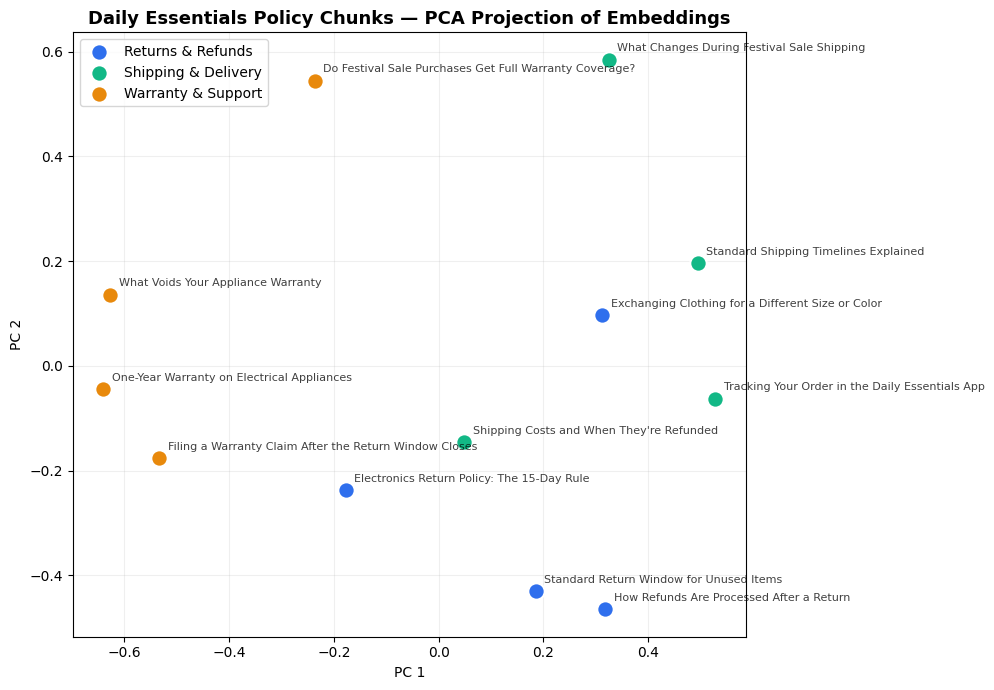

In [6]:
categories = [doc['category'] for doc in documents]
unique_categories = sorted(set(categories))
colors = {"Returns & Refunds": "#2F6FED", "Shipping & Delivery": "#12B886", "Warranty & Support": "#E8890C"}

plt.figure(figsize=(10, 7))
for cat in unique_categories:
    idx = [i for i, c in enumerate(categories) if c == cat]
    plt.scatter(coords_pca[idx, 0], coords_pca[idx, 1],
                label=cat, color=colors[cat], s=140, edgecolors="white", linewidths=1.5, zorder=3)

for i, doc in enumerate(documents):
    plt.annotate(doc['title'], (coords_pca[i, 0], coords_pca[i, 1]),
                 fontsize=8, xytext=(6, 6), textcoords="offset points", alpha=0.75)

plt.title("Daily Essentials Policy Chunks — PCA Projection of Embeddings", fontsize=13, fontweight="bold")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(loc="best", frameon=True)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## t-SNE (an alternative projection)

PCA is fast and deterministic but purely linear. t-SNE often separates
clusters more dramatically — useful for a second look, though the axes
themselves aren't individually meaningful the way PCA's are.

In [7]:
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
coords_tsne = tsne.fit_transform(embeddings)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


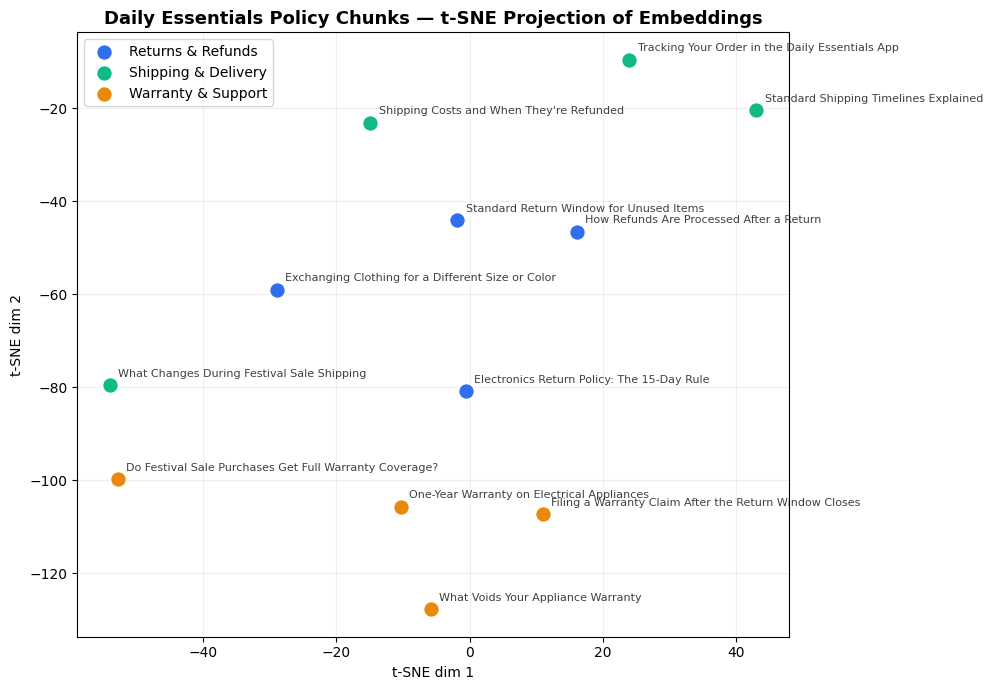

In [8]:
plt.figure(figsize=(10, 7))
for cat in unique_categories:
    idx = [i for i, c in enumerate(categories) if c == cat]
    plt.scatter(coords_tsne[idx, 0], coords_tsne[idx, 1],
                label=cat, color=colors[cat], s=140, edgecolors="white", linewidths=1.5, zorder=3)

for i, doc in enumerate(documents):
    plt.annotate(doc['title'], (coords_tsne[i, 0], coords_tsne[i, 1]),
                 fontsize=8, xytext=(6, 6), textcoords="offset points", alpha=0.75)

plt.title("Daily Essentials Policy Chunks — t-SNE Projection of Embeddings", fontsize=13, fontweight="bold")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.legend(loc="best", frameon=True)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Similarity heatmap

Since the embeddings are normalized, cosine similarity between any two
chunks is just a dot product. The block-diagonal pattern (if it shows up)
is the same-category clustering from the scatter plots, in matrix form.

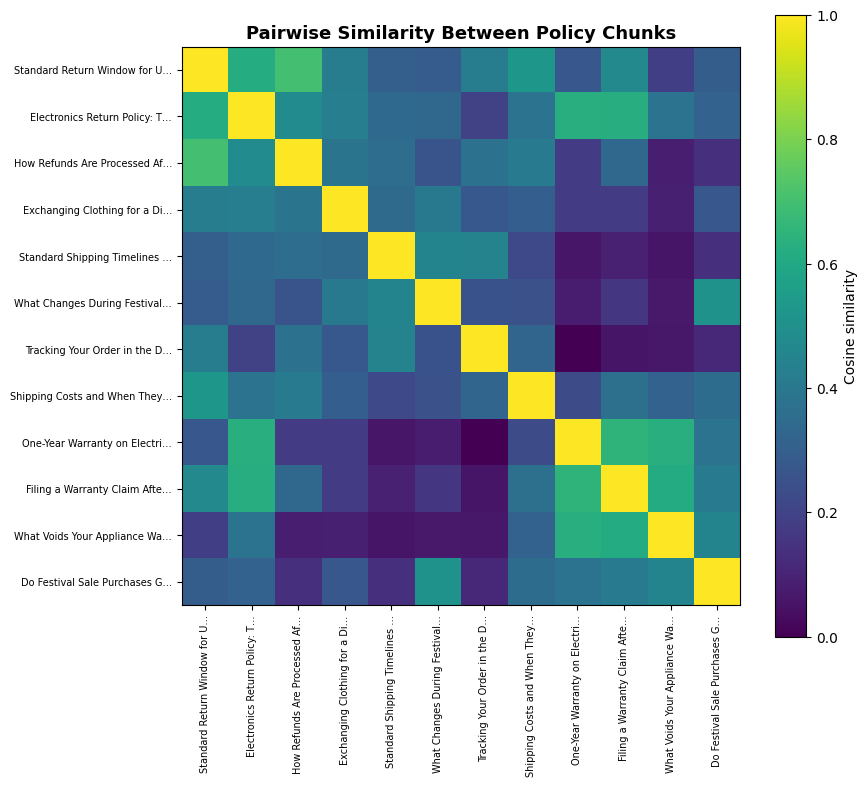

In [9]:
similarity_matrix = embeddings @ embeddings.T

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(similarity_matrix, cmap="viridis", vmin=0, vmax=1)

short_titles = [doc['title'][:28] + ("…" if len(doc['title']) > 28 else "") for doc in documents]
ax.set_xticks(range(len(documents)))
ax.set_yticks(range(len(documents)))
ax.set_xticklabels(short_titles, rotation=90, fontsize=7)
ax.set_yticklabels(short_titles, fontsize=7)

plt.colorbar(im, label="Cosine similarity")
plt.title("Pairwise Similarity Between Policy Chunks", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Query search demo

This is retrieval in action — the same operation `rag.py`'s `search()`
performs. We embed a query, score it against every chunk, and show the
top matches. Try the compound question from Lecture 4: it should pull
chunks from **both** Returns & Refunds *and* Warranty & Support, which is
exactly why that question needs both a Tool and RAG together.

In [10]:
def search(query, k=3):
    query_vec = model.encode([query], normalize_embeddings=True)[0]
    scores = embeddings @ query_vec
    top_idx = np.argsort(scores)[::-1][:k]
    return [(documents[i]['title'], documents[i]['category'], float(scores[i])) for i in top_idx]


query = "I bought a mixer during the Diwali sale and it stopped working after 20 days"
print(f"Query: {query!r}\n")
for title, category, score in search(query):
    print(f"  {score:.3f}  [{category}]  {title}")

Query: 'I bought a mixer during the Diwali sale and it stopped working after 20 days'

  0.463  [Returns & Refunds]  Electronics Return Policy: The 15-Day Rule
  0.431  [Shipping & Delivery]  What Changes During Festival Sale Shipping
  0.358  [Warranty & Support]  One-Year Warranty on Electrical Appliances


In [11]:
# Try a few more queries and see which categories they pull from
for query in [
    "How long do I have to return clothing?",
    "When will I get my money back after a return?",
    "Does the warranty still apply if I bought it on sale?",
]:
    print(f"Query: {query!r}")
    for title, category, score in search(query, k=2):
        print(f"  {score:.3f}  [{category}]  {title}")
    print()

Query: 'How long do I have to return clothing?'
  0.618  [Returns & Refunds]  Exchanging Clothing for a Different Size or Color
  0.551  [Returns & Refunds]  Standard Return Window for Unused Items

Query: 'When will I get my money back after a return?'
  0.565  [Returns & Refunds]  How Refunds Are Processed After a Return
  0.509  [Returns & Refunds]  Electronics Return Policy: The 15-Day Rule

Query: 'Does the warranty still apply if I bought it on sale?'
  0.553  [Warranty & Support]  Do Festival Sale Purchases Get Full Warranty Coverage?
  0.515  [Warranty & Support]  Filing a Warranty Claim After the Return Window Closes

